In [61]:
from IPython.display import HTML
from ipywidgets import interact, fixed, IntSlider
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.ndimage import distance_transform_edt, zoom
import torch
from typing import List, Tuple

SEED: int = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

## Environment Generation

In [62]:
WORLD_SIZE: Tuple[int, int] = (1000, 1000)
START_POSITION: Tuple[int, int] = (1, 1)
END_POSITION: Tuple[int, int] = (999, 999)
PATH_COST: float = 1.0
NUM_SPLINE_SAMPLES: int = 10000
NUM_SPLINE_INTERPOLATIONS: int = 100
SPLINE_POINTS_BEGINNING: List[Tuple[int, int]] = [
    START_POSITION,
    (200, 200),
    (200, 400),
    (500, 500),
    (800, 600),
    (800, 800),
    END_POSITION
]
SPLINE_POINTS_END: List[Tuple[int, int]] = [
    START_POSITION,
    (200, 900),
    (200, 750),
    (500, 500),
    (800, 250),
    (800, 100),
    END_POSITION
]
NUM_SPATIAL_SAMPLES: int = 10000

In [63]:
def create_spline(points: List[Tuple[int, int]], num_samples: int) -> np.ndarray:
    x_points = [p[0] for p in points]
    y_points = [p[1] for p in points]

    cs = CubicSpline(
        np.linspace(0, 1, len(x_points)),
        np.vstack([x_points, y_points]), axis=1
    )
    t = np.linspace(0, 1, num_samples)
    spline_points = cs(t).T
    return spline_points

def create_costmap(world: np.ndarray, spline_points: np.ndarray, path_cost: float) -> np.ndarray:
    costmap = np.zeros(world.shape)
    for point in spline_points:
        x, y = int(point[0]), int(point[1])
        if 0 <= x < world.shape[0] and 0 <= y < world.shape[1]:
            costmap[x, y] = path_cost

    path_mask = (costmap == path_cost)
    distances = distance_transform_edt(~path_mask)
    costmap = 1 + distances
    return costmap

def plot_costmaps(
        costmaps: List[np.ndarray],
        start_position: np.ndarray,
        end_position: np.ndarray,
        titles: List[str] = None
    ):

    if titles is None:
        titles = ['Costmap'] * len(costmaps)

    fig, axes = plt.subplots(1, len(costmaps), figsize=(10, 5))
    for ax, costmap, title in zip(axes, costmaps, titles):
        ax.imshow(costmap, cmap='viridis', interpolation='nearest', origin='lower')
        ax.plot(*start_position[::-1], 'g', marker="X")  # Start position
        ax.plot(*end_position[::-1], 'r', marker="X")    # End position
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# create a discretized version of the cost maps
def create_discretized_costmaps(cost_maps: List[np.ndarray], num_samples: int) -> List[np.ndarray]:
    """
    convert the continuous valued cost maps into a discretized version
    """
    discretized_maps = []
    for cost_map in cost_maps:
        normalized_map = (cost_map - cost_map.min()) / (cost_map.max() - cost_map.min())
        # Create a new map with the same shape but discretized values
        discretized_map = np.digitize(normalized_map, bins=np.linspace(0, 1, num_samples))
        discretized_maps.append(discretized_map)
    return discretized_maps

def animate_costmaps(
    costmaps: List[np.ndarray],
    start_position: np.ndarray,
    end_position: np.ndarray,
    titles: List[str] = None,
    interval: int = 20,  # milliseconds between frames
    save_path: str = None  # optional: path to save the animation
):
    if titles is None:
        titles = ['Costmap'] * len(costmaps)

    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Initialize the first frame
    im = ax.imshow(
        costmaps[0],
        cmap='viridis',
        interpolation='nearest',
        origin='lower'
    )
    start_marker, = ax.plot(
        *start_position[::-1],
        'g',
        marker="X",
        markersize=10
    )
    end_marker, = ax.plot(
        *end_position[::-1],
        'r',
        marker="X",
        markersize=10
    )
    title_text = ax.set_title(titles[0])
    ax.axis('off')

    def update(frame):
        im.set_data(costmaps[frame])
        title_text.set_text(titles[frame])
        return [im, title_text, start_marker, end_marker]

    ani = animation.FuncAnimation(
        fig, update, frames=len(costmaps), interval=interval, blit=True
    )

    if save_path is not None:
        ani.save(save_path, writer='ffmpeg', dpi=150)

    plt.close(fig)  # Close the figure to avoid displaying it inline

    return ani

In [64]:
world = np.zeros(WORLD_SIZE)
start_costmap = create_costmap(
    world,
    create_spline(SPLINE_POINTS_BEGINNING, NUM_SPLINE_SAMPLES),
    PATH_COST
)
end_costmap = create_costmap(
    world,
    create_spline(SPLINE_POINTS_END, NUM_SPLINE_SAMPLES),
    PATH_COST
)

start_costmap += 10
end_costmap += 10

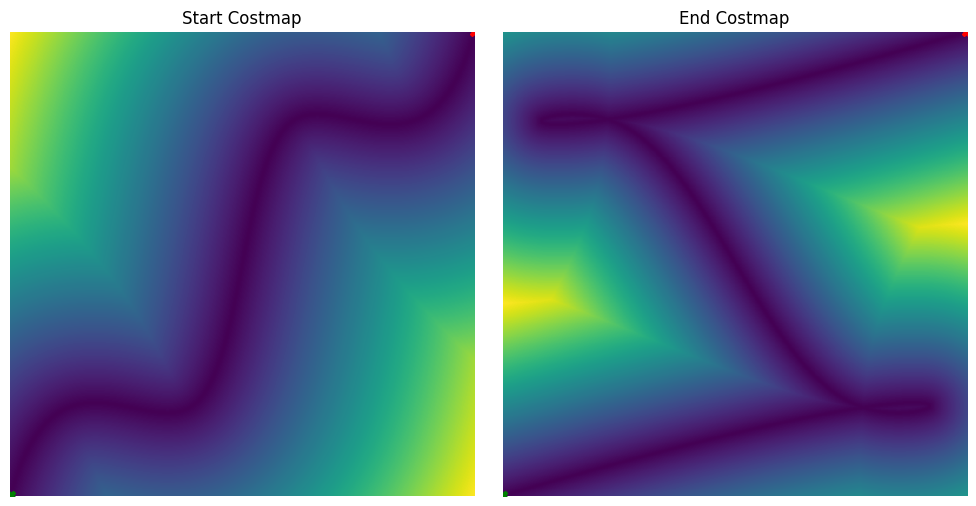

In [65]:
plot_costmaps(
    [start_costmap, end_costmap],
    START_POSITION,
    END_POSITION,
    titles=["Start Costmap", "End Costmap"]
)

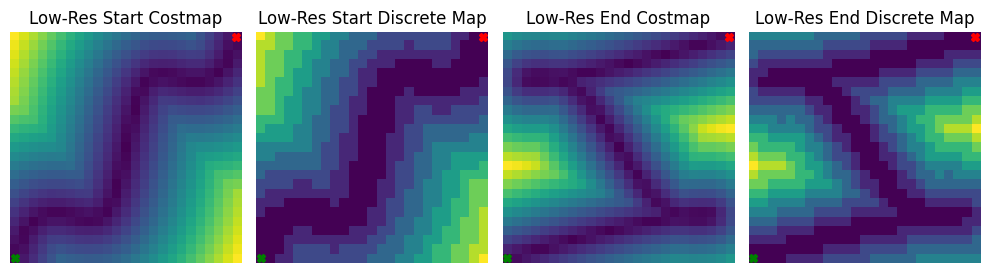

In [66]:
downscale_factor = 0.025
low_res_start_costmap = zoom(start_costmap, downscale_factor, order=1)
low_res_end_costmap = zoom(end_costmap, downscale_factor, order=1)

low_res_start_pos = ((START_POSITION[0]) - 1, (START_POSITION[1])-1)
low_res_end_pos = ((END_POSITION[0] * downscale_factor) - 1, (END_POSITION[1] * downscale_factor)-1)

num_bins = 10

discrete_maps = create_discretized_costmaps([low_res_start_costmap, low_res_end_costmap], num_bins)

discrete_maps = [x + 1 for x in discrete_maps]

plot_costmaps(
    [low_res_start_costmap, discrete_maps[0], low_res_end_costmap, discrete_maps[1]],
    low_res_start_pos,
    low_res_end_pos,
    titles=["Low-Res Start Costmap", "Low-Res Start Discrete Map", "Low-Res End Costmap", "Low-Res End Discrete Map"]
)

## Data Generation

In [67]:
def convert_costmap_to_points(costmap: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Convert a costmap to a set of points sampled according to the cost distribution.
    """
    # Get coordinates
    x_indices, y_indices = np.meshgrid(
        np.arange(costmap.shape[1]),  # x = columns
        np.arange(costmap.shape[0])   # y = rows
    )

    # Flatten to a list of (x, y) points
    points = np.stack([x_indices.ravel(), y_indices.ravel()], axis=-1)

    # Flatten the costmap values
    labels = costmap.ravel()

    # Subtract 1 from all labels to ensure they are zero-indexed
    labels -= 1
    return points, labels

In [68]:
# ------------------------------------
# Convert the maps into points - X, y
# ------------------------------------
X_start_cost, y_start_cost = convert_costmap_to_points(low_res_start_costmap) # type: ignore
X_end_cost, y_end_cost = convert_costmap_to_points(low_res_end_costmap)       # type: ignore
X_start_dis, y_start_dis = convert_costmap_to_points(discrete_maps[0])        # type: ignore
X_end_dis, y_end_dis = convert_costmap_to_points(discrete_maps[1])          # type: ignore

# --------------------------------
# Convert the points into tensors
# --------------------------------
X_start_cost: torch.Tensor = torch.from_numpy(X_start_cost)
y_start_cost: torch.Tensor = torch.from_numpy(y_start_cost)
X_end_cost: torch.Tensor = torch.from_numpy(X_end_cost)
y_end_cost: torch.Tensor = torch.from_numpy(y_end_cost)
X_start_dis: torch.Tensor = torch.from_numpy(X_start_dis)
y_start_dis: torch.Tensor = torch.from_numpy(y_start_dis)
X_end_dis: torch.Tensor = torch.from_numpy(X_end_dis)
y_end_dis: torch.Tensor = torch.from_numpy(y_end_dis)

# ---------------------------
# Convert them to 2D tensors
# ---------------------------
y_start_cost = y_start_cost.unsqueeze(-1)
y_end_cost = y_end_cost.unsqueeze(-1)
y_start_dis = y_start_dis.unsqueeze(-1)
y_end_dis = y_end_dis.unsqueeze(-1)

# ---------------------------
# Print their shape and type
# ---------------------------
def print_st(m, n):
    print(f"{n} Shape: {m.shape}; Type: {type(m)}")

print_st(X_start_cost, "X_start_cost")
print_st(y_start_cost, "y_start_cost")
print_st(X_end_cost, "X_end_cost")
print_st(y_end_cost, "y_end_cost")
print_st(X_start_dis, "X_start_dis")
print_st(y_start_dis, "y_start_dis")
print_st(X_end_dis, "X_end_dis")
print_st(y_end_dis, "y_end_dis")

X_start_cost Shape: torch.Size([625, 2]); Type: <class 'torch.Tensor'>
y_start_cost Shape: torch.Size([625, 1]); Type: <class 'torch.Tensor'>
X_end_cost Shape: torch.Size([625, 2]); Type: <class 'torch.Tensor'>
y_end_cost Shape: torch.Size([625, 1]); Type: <class 'torch.Tensor'>
X_start_dis Shape: torch.Size([625, 2]); Type: <class 'torch.Tensor'>
y_start_dis Shape: torch.Size([625, 1]); Type: <class 'torch.Tensor'>
X_end_dis Shape: torch.Size([625, 2]); Type: <class 'torch.Tensor'>
y_end_dis Shape: torch.Size([625, 1]); Type: <class 'torch.Tensor'>


In [69]:
def train_test_split(
    x: torch.Tensor,
    y: torch.Tensor,
    test_size: float
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Randomly split tensors into train and test subsets.

    Parameters
    ----------
    x : torch.Tensor
        Input tensor of shape (N, ...).
    y : torch.Tensor
        Target tensor of shape (N, ...).
    test_size : float
        Fraction of samples to allocate to the test split.
        Must satisfy 0 < test_size < 1.

    Returns
    -------
    x_train, y_train, x_test, y_test : Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]
        Split tensors.
    """

    # ----------------------
    # Validation
    # ----------------------
    if not isinstance(x, torch.Tensor):
        raise TypeError(f"x must be a torch.Tensor; got {type(x)}")

    if not isinstance(y, torch.Tensor):
        raise TypeError(f"y must be a torch.Tensor; got {type(y)}")

    if x.shape[0] != y.shape[0]:
        raise ValueError(
            f"x and y must have the same number of samples; "
            f"got x={x.shape[0]}, y={y.shape[0]}"
        )

    if not isinstance(test_size, float):
        raise TypeError(f"test_size must be a float; got {type(test_size)}")

    if not (0.0 < test_size < 1.0):
        raise ValueError("test_size must be in the interval (0, 1)")

    # ----------------------
    # Split logic
    # ----------------------
    n_samples = x.shape[0]
    n_test = int(round(n_samples * test_size))
    n_train = n_samples - n_test

    if n_test == 0 or n_train == 0:
        raise ValueError(
            f"test_size={test_size} results in an empty split "
            f"(n_samples={n_samples})"
        )

    # Random permutation of indices
    perm = torch.randperm(n_samples, device=x.device)

    train_idx = perm[:n_train]
    test_idx = perm[n_train:]

    x_train = x[train_idx]
    y_train = y[train_idx]
    x_test  = x[test_idx]
    y_test  = y[test_idx]

    return x_train, y_train, x_test, y_test

In [70]:
TEST_SIZE = 0.2

(
    X_start_cost_train, y_start_cost_train,
    X_start_cost_test, y_start_cost_test,
) = train_test_split(X_start_cost, y_start_cost, TEST_SIZE)

(
    X_end_cost_train, y_end_cost_train,
    X_end_cost_test, y_end_cost_test,
) = train_test_split(X_end_cost, y_end_cost, TEST_SIZE)

(
    X_start_dis_train, y_start_dis_train,
    X_start_dis_test, y_start_dis_test,
) = train_test_split(X_start_dis, y_start_dis, TEST_SIZE)

(
    X_end_dis_train, y_end_dis_train,
    X_end_dis_test, y_end_dis_test,
) = train_test_split(X_end_dis, y_end_dis, TEST_SIZE)


In [71]:
def plot_split_2d_and_value(
    X_tr: torch.Tensor, y_tr: torch.Tensor,
    X_te: torch.Tensor, y_te: torch.Tensor,
    title: str,
    value_mode: str = "index",   # "index" | "hist"
    s_xy: float = 6.0,
    s_val: float = 8.0,
):
    """
    Plot (1) XY scatter with colors by split, and (2) value plot colored by split.

    Assumes X is (N,2) with columns [x,y], and y is (N,1) or (N,).
    """
    # ---- basic checks / shaping
    if X_tr.ndim != 2 or X_tr.shape[1] < 2:
        raise ValueError(f"{title}: expected X_tr shape (N,2+); got {tuple(X_tr.shape)}")
    if X_te.ndim != 2 or X_te.shape[1] < 2:
        raise ValueError(f"{title}: expected X_te shape (N,2+); got {tuple(X_te.shape)}")

    y_tr_ = y_tr.squeeze(-1) if y_tr.ndim > 1 else y_tr
    y_te_ = y_te.squeeze(-1) if y_te.ndim > 1 else y_te

    # ---- move to cpu for plotting
    X_tr_cpu = X_tr.detach().cpu()
    X_te_cpu = X_te.detach().cpu()
    y_tr_cpu = y_tr_.detach().cpu()
    y_te_cpu = y_te_.detach().cpu()

    # ---- build figure
    fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    fig.suptitle(title)

    # (A) XY scatter
    ax[0].scatter(X_tr_cpu[:, 0], X_tr_cpu[:, 1], s=s_xy, label="train", alpha=0.7)
    ax[0].scatter(X_te_cpu[:, 0], X_te_cpu[:, 1], s=s_xy, label="test",  alpha=0.7)
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y")
    ax[0].set_title("XY plane (colored by split)")
    ax[0].legend()
    ax[0].set_aspect("equal")

    # (B) Value plot
    if value_mode == "index":
        ax[1].scatter(torch.arange(len(y_tr_cpu)), y_tr_cpu, s=s_val, label="train", alpha=0.7)
        ax[1].scatter(torch.arange(len(y_te_cpu)), y_te_cpu, s=s_val, label="test",  alpha=0.7)
        ax[1].set_xlabel("sample index (within split)")
        ax[1].set_ylabel("value")
        ax[1].set_title("Value vs index (colored by split)")
        ax[1].legend()

    elif value_mode == "hist":
        ax[1].hist(y_tr_cpu.numpy(), bins=50, alpha=0.6, label="train")
        ax[1].hist(y_te_cpu.numpy(), bins=50, alpha=0.6, label="test")
        ax[1].set_xlabel("value")
        ax[1].set_ylabel("count")
        ax[1].set_title("Value histogram (colored by split)")
        ax[1].legend()

    else:
        raise ValueError("value_mode must be 'index' or 'hist'")

    plt.show()


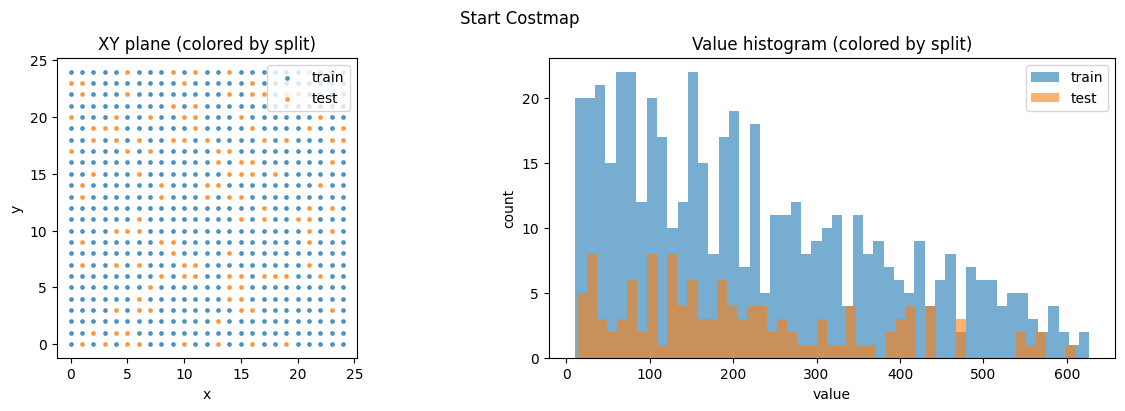

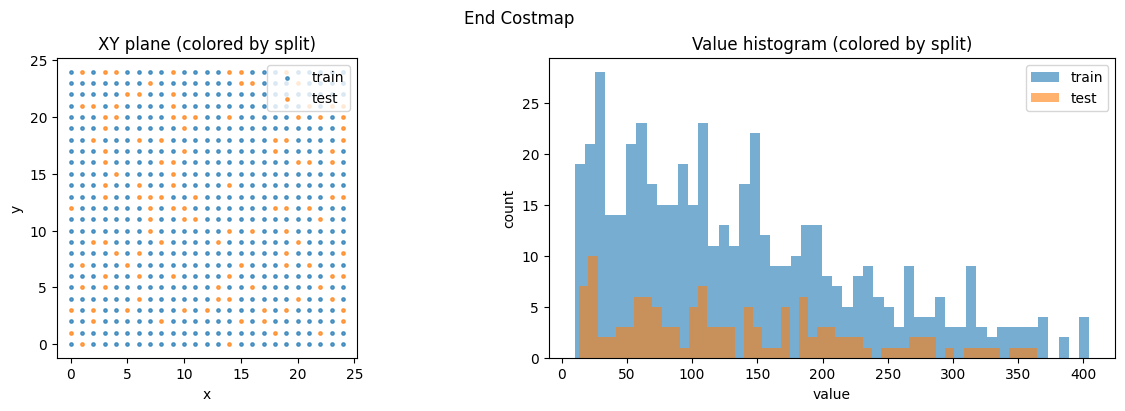

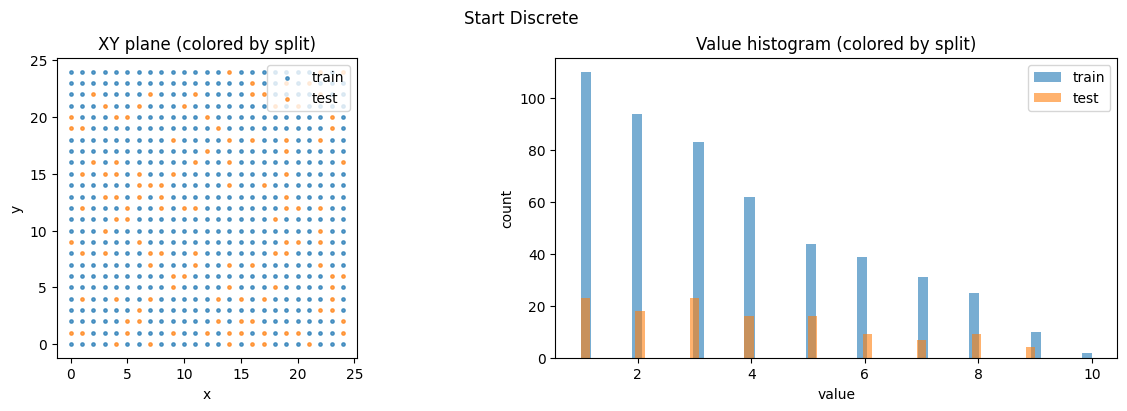

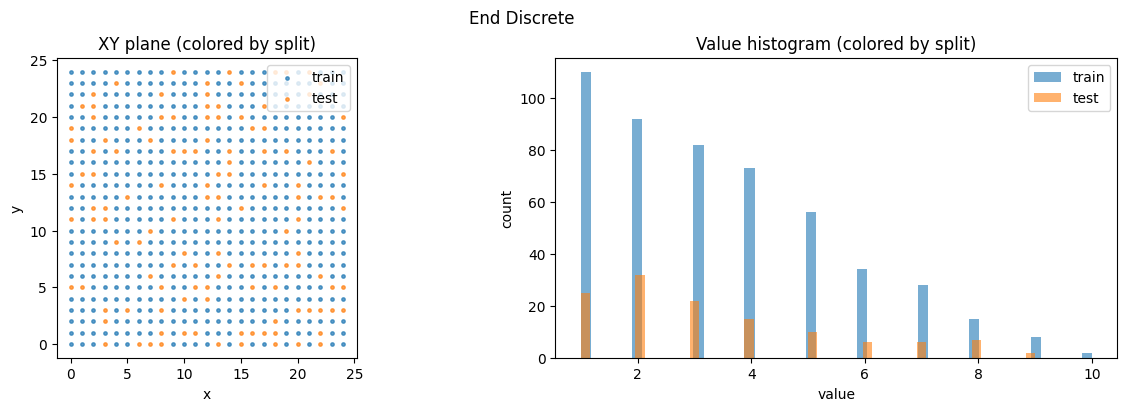

In [72]:
plot_split_2d_and_value(
    X_start_cost_train, y_start_cost_train,
    X_start_cost_test, y_start_cost_test,
    title="Start Costmap",
    value_mode="hist"
)

plot_split_2d_and_value(
    X_end_cost_train, y_end_cost_train,
    X_end_cost_test, y_end_cost_test,
    title="End Costmap",
    value_mode="hist"
)

plot_split_2d_and_value(
    X_start_dis_train, y_start_dis_train,
    X_start_dis_test, y_start_dis_test,
    title="Start Discrete",
    value_mode="hist"
)

plot_split_2d_and_value(
    X_end_dis_train, y_end_dis_train,
    X_end_dis_test, y_end_dis_test,
    title="End Discrete",
    value_mode="hist"
)

## HyperSpace Initialization

In [73]:
from hyperspace.backends import HRRBackend

VSA_CONFIG: dict = {
    "vector_dim": 2048,
    "vector_length_scale": 1.0,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

In [74]:
backend = HRRBackend(
    vector_dim=VSA_CONFIG["vector_dim"],
    length_scale=VSA_CONFIG["vector_length_scale"],
    device=VSA_CONFIG["device"],
    env_dim=2
)

### Initialize Ground Truth Vectors

In [75]:
X_inputs = {
    "X_start_cost":       X_start_cost,
    "X_start_cost_train": X_start_cost_train,
    "X_start_cost_test":  X_start_cost_test,
    "X_end_cost":         X_end_cost,
    "X_end_cost_train":   X_end_cost_train,
    "X_end_cost_test":    X_end_cost_test,
    "X_start_dis":        X_start_dis,
    "X_start_dis_train":  X_start_dis_train,
    "X_start_dis_test":   X_start_dis_test,
    "X_end_dis":          X_end_dis,
    "X_end_dis_train":    X_end_dis_train,
    "X_end_dis_test":     X_end_dis_test,
}

y_inputs = {
    "y_start_cost":       y_start_cost,
    "y_start_cost_train": y_start_cost_train,
    "y_start_cost_test":  y_start_cost_test,
    "y_end_cost":         y_end_cost,
    "y_end_cost_train":   y_end_cost_train,
    "y_end_cost_test":    y_end_cost_test,
    "y_start_dis":        y_start_dis,
    "y_start_dis_train":  y_start_dis_train,
    "y_start_dis_test":   y_start_dis_test,
    "y_end_dis":          y_end_dis,
    "y_end_dis_train":    y_end_dis_train,
    "y_end_dis_test":     y_end_dis_test,
}

X_vectors = {}

for name, x in X_inputs.items():
    x_vecs, _ = backend.positional_encoding(x)
    X_vectors[f"{name}_vectors"] = x_vecs

y_vectors = {}

for name, y in y_inputs.items():
    y_vecs, _ = backend.value_encoding(y)
    y_vectors[f"{name}_vectors"] = y_vecs

for split in ["start_cost_train", "start_cost_test",
              "end_cost_train", "end_cost_test",
              "start_dis_train", "start_dis_test",
              "end_dis_train", "end_dis_test"]:
    assert X_vectors[f"X_{split}_vectors"].shape[0] == \
           y_vectors[f"y_{split}_vectors"].shape[0]
    assert X_vectors[f"X_{split}_vectors"].shape[-1] == VSA_CONFIG["vector_dim"]
    assert y_vectors[f"y_{split}_vectors"].shape[-1] == VSA_CONFIG["vector_dim"]

for k, v in X_vectors.items():
    print_st(v, k)

for k, v in y_vectors.items():
    print_st(v, k)

X_start_cost_vectors Shape: torch.Size([625, 2048]); Type: <class 'torch.Tensor'>
X_start_cost_train_vectors Shape: torch.Size([500, 2048]); Type: <class 'torch.Tensor'>
X_start_cost_test_vectors Shape: torch.Size([125, 2048]); Type: <class 'torch.Tensor'>
X_end_cost_vectors Shape: torch.Size([625, 2048]); Type: <class 'torch.Tensor'>
X_end_cost_train_vectors Shape: torch.Size([500, 2048]); Type: <class 'torch.Tensor'>
X_end_cost_test_vectors Shape: torch.Size([125, 2048]); Type: <class 'torch.Tensor'>
X_start_dis_vectors Shape: torch.Size([625, 2048]); Type: <class 'torch.Tensor'>
X_start_dis_train_vectors Shape: torch.Size([500, 2048]); Type: <class 'torch.Tensor'>
X_start_dis_test_vectors Shape: torch.Size([125, 2048]); Type: <class 'torch.Tensor'>
X_end_dis_vectors Shape: torch.Size([625, 2048]); Type: <class 'torch.Tensor'>
X_end_dis_train_vectors Shape: torch.Size([500, 2048]); Type: <class 'torch.Tensor'>
X_end_dis_test_vectors Shape: torch.Size([125, 2048]); Type: <class 'torch

## Compare position vectors to the ground truth

In [ ]:
def plot_position_vs_gt(t, gt_vectors, vectors, positions):

    sv = vectors[t]
    sp = positions[t]

    sims, _ = backend.similarity(sv, gt_vectors)

    N = int(np.sqrt(sims.shape[0]))

    sims_2d = sims.reshape(N, N)

    plt.imshow(sims_2d)
    plt.title(f"Position: X={sp[0]}; Y={sp[1]}")

t = 0
gt_vectors = X_vectors["X_start_cost_vectors"]
sample_vectors = X_vectors["X_start_cost_train_vectors"]
sample_positions = X_inputs["X_start_cost_train"]

T = sample_vectors.shape[0]

interact(
    lambda t: plot_position_vs_gt(t, gt_vectors, sample_vectors, sample_positions),
    t=IntSlider(value=0, min=0, max=T-1, step=1, continuous_update=False)
)

interactive(children=(IntSlider(value=0, continuous_update=False, description='t', max=499), Output()), _dom_c…

<function __main__.<lambda>(t)>